# XGBoost: classificazione di feature reali e sintetiche

> **Abstract**  
> Questo notebook addestra e confronta classificatori XGBoost binari sulle feature tabulari estratte dalle mappe spaziali: mean+std, configurazione primaria da 2560 feature, e GAP, ablation da 1280 feature. Carica lo split condiviso, verifica allineamento e integrità delle cache e usa due studi bayesiani Optuna TPE, uno per ciascun pooling, per scegliere gli iperparametri con balanced accuracy sulla validation. TPE esplora inizialmente lo spazio discreto definito dal progetto e poi concentra i trial sulle combinazioni più promettenti; pruning ed early stopping interrompono i trial deboli. Il test non viene consultato durante la ricerca. Il modello selezionato viene calibrato con Platt scaling e il notebook salva probabilità e predizioni per campione, metriche, curve, studio Optuna e bundle portabile per l'ensemble.

Obiettivo: confrontare XGBoost sulle rappresentazioni tabulari mean+std e GAP. Mean+std è la configurazione primaria; GAP è un'ablation. La balanced accuracy di validation seleziona pooling, trial TPE, numero di boosting round e soglia. Il test resta isolato fino alla valutazione finale.

Input: cache prodotte da dataset_exploration.ipynb. Hardware previsto: esecuzione CPU con tree_method hist; il notebook non presuppone una GPU.

## Schema della pipeline

```text
Dataset e cache condivise
        |
        v
Caricamento e controlli di integrita'
  - sample_index.csv
  - feature mean+std (2560)
  - feature GAP (1280)
        |
        v
Split stratificato seed 42
  train 70% | validation 15% | test 15%
        |
        v
Due studi Optuna TPE indipendenti
  mean+std ------------------+
  GAP ------------------------+--> XGBoost + early stopping
                                  |
                                  v
              Selezione su validation
                                  |
                                  v
        Refit del modello e calibrazione Platt
                                  |
                                  v
          Soglia scelta sulla validation
                                  |
                                  v
       Valutazione finale sul test isolato
                                  |
                                  v
 Metriche, predizioni, figure e bundle persistente
```

**Spiegazione.** Il notebook parte dalle cache tabulari prodotte dal notebook esplorativo e verifica dimensioni, tipo, allineamento delle righe, label e split. Le rappresentazioni mean+std e GAP vengono analizzate separatamente per mantenere confrontabile l'effetto del pooling. Per ciascuna rappresentazione Optuna esplora gli iperparametri XGBoost con il sampler TPE; la balanced accuracy sulla validation guida la selezione, mentre pruning ed early stopping limitano i fit poco promettenti.

Il miglior modello tra i due studi viene rifittato usando lo stop determinato dalla validation. I margini XGBoost sono convertiti in probabilita' tramite calibrazione di Platt e la soglia decisionale viene fissata sempre sulla validation. Solo a questo punto il test viene utilizzato per la valutazione finale. Infine il notebook salva metriche, predizioni, grafici, modello nativo JSON e bundle joblib per l'ensemble.

## 1. Setup portabile e riproducibilità

Questa è l'unica cella che distingue locale e Colab. In Colab i file originali sono copiati temporaneamente nella VM, mentre cache, artefatti e risultati rimangono su Drive. XGBoost legge le sole cache persistenti, ma la cella mantiene il contratto comune dei notebook. Optuna e la sua integrazione XGBoost sono installate condizionalmente solo se mancanti, così lo stesso file esegue la ricerca TPE su entrambe le piattaforme.

In [6]:
# Import diretto protetto: in locale il namespace google può non essere presente.
from pathlib import Path
import importlib.util
import shutil

try:
    from google.colab import drive as colab_drive
    IS_COLAB = True
except ImportError:
    colab_drive = None
    IS_COLAB = False

EXPECTED_FILES = {'features_0.npy': 2_167_931_008, 'features_1.npy': 3_123_445_888}
if IS_COLAB:
    DRIVE_MOUNT = Path('/content/drive')
    if not (DRIVE_MOUNT / 'MyDrive').exists():
        colab_drive.mount(str(DRIVE_MOUNT), force_remount=False)
    PROJECT_ROOT = DRIVE_MOUNT / 'MyDrive' / 'Magistrale' / 'Advanced_ML' / 'progetto_aml'
    PERSISTENT_DATASET_DIR = PROJECT_ROOT / 'dataset'
    if not PERSISTENT_DATASET_DIR.is_dir():
        raise FileNotFoundError(f'Dataset directory non trovata su Drive: {PERSISTENT_DATASET_DIR}')
    RUNTIME_DATASET_DIR = Path('/content/progetto_aml/dataset')
    RUNTIME_DATASET_DIR.mkdir(parents=True, exist_ok=True)
    for filename, expected_size in EXPECTED_FILES.items():
        source, destination = PERSISTENT_DATASET_DIR / filename, RUNTIME_DATASET_DIR / filename
        if not source.is_file():
            raise FileNotFoundError(f'File originale mancante: {source}')
        if source.stat().st_size != expected_size:
            raise RuntimeError(f'Dimensione inattesa per {source}: {source.stat().st_size}; attesi {expected_size}')
        if not destination.exists() or destination.stat().st_size != expected_size:
            print(f'Copio {filename} da Drive nella VM Colab')
            shutil.copy2(source, destination)
        if destination.stat().st_size != expected_size:
            raise RuntimeError(f'Copia incompleta: {destination}')
    DATASET_DIR = RUNTIME_DATASET_DIR
    PROCESSED_DATASET_DIR = PERSISTENT_DATASET_DIR
    ARTIFACTS_DIR, RESULTS_DIR = PROJECT_ROOT / 'artifacts', PROJECT_ROOT / 'results'
else:
    PROJECT_ROOT = Path.cwd()
    if not (PROJECT_ROOT / 'dataset').is_dir():
        PROJECT_ROOT = PROJECT_ROOT.parent
    PERSISTENT_DATASET_DIR = PROJECT_ROOT / 'dataset'
    DATASET_DIR = PERSISTENT_DATASET_DIR
    PROCESSED_DATASET_DIR = PERSISTENT_DATASET_DIR
    ARTIFACTS_DIR, RESULTS_DIR = PROJECT_ROOT / 'artifacts', PROJECT_ROOT / 'results'

if not PERSISTENT_DATASET_DIR.is_dir():
    raise FileNotFoundError(f'Dataset directory non trovata: {PERSISTENT_DATASET_DIR}')
for directory in (ARTIFACTS_DIR, RESULTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)
print('Ambiente:', 'Google Colab' if IS_COLAB else 'Locale')
print('Cache persistenti:', PROCESSED_DATASET_DIR)
print('Risultati persistenti:', RESULTS_DIR)

Ambiente: Locale
Cache persistenti: c:\Users\leona\venv_aml\dataset
Risultati persistenti: c:\Users\leona\venv_aml\results


In [7]:
# Installa solo dipendenze assenti e raccoglie le versioni necessarie alla riproducibilità.
import subprocess
import sys

required_packages = {'numpy': 'numpy', 'pandas': 'pandas', 'matplotlib': 'matplotlib', 'sklearn': 'scikit-learn', 'xgboost': 'xgboost', 'joblib': 'joblib', 'optuna': 'optuna', 'optuna_integration': 'optuna-integration[xgboost]'}
missing_packages = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing_packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', *missing_packages])

import hashlib
import json
import os
import platform
import random
import time
from datetime import datetime, timezone

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import optuna
import xgboost as xgb
from IPython.display import display
from optuna_integration import XGBoostPruningCallback
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, balanced_accuracy_score, brier_score_loss, confusion_matrix, f1_score, log_loss, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

try:
    import torch
except ImportError:
    torch = None

SEED = 42
POOLING_CHOICES = ('mean_std', 'gap')
MAX_BOOSTING_ROUNDS = 1000
EARLY_STOPPING_ROUNDS = 50
# TPE seleziona in modo adattivo i trial promettenti senza cambiare lo spazio discreto definito dal progetto.
N_OPTUNA_TRIALS_PER_POOLING = 32
N_STARTUP_TRIALS = 8
PRUNER_WARMUP_STEPS = 30
SEARCH_SPACE = {'max_depth': [3, 4, 5, 6], 'learning_rate': [0.02, 0.05, 0.1], 'subsample': [0.7, 0.85, 1.0], 'colsample_bytree': [0.5, 0.75, 1.0], 'min_child_weight': [1, 5, 10]}
USE_CLASS_WEIGHT_ABLATION = True
RUN_ID = f'seed{SEED}_{datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")}'
MODEL_NAME = 'xgboost'
RUN_DIR = RESULTS_DIR / MODEL_NAME / RUN_ID
FIGURES_DIR = RUN_DIR / 'figures'
RUN_DIR.mkdir(parents=True, exist_ok=False)
FIGURES_DIR.mkdir(parents=True, exist_ok=False)

random.seed(SEED)
np.random.seed(SEED)
if torch is not None:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
VERSIONS = {'python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__, 'scikit_learn': __import__('sklearn').__version__, 'xgboost': xgb.__version__, 'pytorch': None if torch is None else torch.__version__, 'cuda': None if torch is None or not torch.cuda.is_available() else torch.version.cuda}
print(json.dumps(VERSIONS, indent=2))
print('XGBoost usa CPU con tree_method=hist; nessuna GPU è richiesta.')
print('Run directory:', RUN_DIR)

{
  "python": "3.12.10",
  "numpy": "2.5.2",
  "pandas": "3.0.5",
  "scikit_learn": "1.9.1",
  "xgboost": "3.4.1",
  "pytorch": "2.14.0+cu126",
  "cuda": "12.6"
}
XGBoost usa CPU con tree_method=hist; nessuna GPU è richiesta.
Run directory: c:\Users\leona\venv_aml\results\xgboost\seed42_20260916T142429Z


## 2. Classi, split condiviso e utilità

Le label sono fissate a 0 = real e 1 = fake. Il file di split viene verificato per copertura, disgiunzione e hash; se non esiste viene creato con l'identica procedura stratificata del notebook esplorativo.

**Caratteristiche dello split condiviso.** Gli indici fanno riferimento alle righe di sample_index.csv e delle due cache, quindi ogni notebook usa esattamente gli stessi campioni nelle stesse partizioni. Con seed 42 lo split è stratificato sulla label e suddivide i 4037 campioni in train (70%, 2825 campioni: 1157 real e 1668 fake), validation (15%, 606 campioni: 248 real e 358 fake) e test (15%, 606 campioni: 249 real e 357 fake). Train è l'unica partizione impiegata per apprendere gli alberi; validation guida i trial TPE, il pruning, l'early stopping, la calibrazione e la soglia; test è riservato alla misura finale. Gli insiemi devono essere disgiunti, coprire tutti i campioni e avere un hash stabile comune. Non essendo disponibili ID di gruppo, questo è uno split casuale stratificato e non può escludere eventuali correlazioni tra sorgenti non annotate.

In [8]:
# Mapping esplicito comune a tutti i modelli e all'ensemble.
CLASS_MAPPING = {'features_0.npy': {'label': 0, 'name': 'real'}, 'features_1.npy': {'label': 1, 'name': 'fake'}}
POSITIVE_LABEL, POSITIVE_CLASS = 1, 'fake'
assert CLASS_MAPPING['features_1.npy'] == {'label': POSITIVE_LABEL, 'name': POSITIVE_CLASS}
N_REAL, N_FAKE, N_TOTAL = 1654, 2383, 4037
labels = np.concatenate((np.zeros(N_REAL, dtype=np.int8), np.ones(N_FAKE, dtype=np.int8)))

def atomic_json(payload, path):
    temporary = path.with_name(path.name + '.tmp')
    with temporary.open('w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2, ensure_ascii=False, default=str)
    os.replace(temporary, path)

def atomic_csv(frame, path):
    temporary = path.with_name(path.name + '.tmp')
    frame.to_csv(temporary, index=False)
    os.replace(temporary, path)

def save_split(path, train_indices, validation_indices, test_indices):
    temporary = path.with_name(path.name + '.tmp')
    with temporary.open('wb') as handle:
        np.savez_compressed(handle, train_indices=train_indices, validation_indices=validation_indices, test_indices=test_indices)
    os.replace(temporary, path)

def stable_split_hash(train_indices, validation_indices, test_indices):
    digest = hashlib.sha256()
    for name, values in (('train', train_indices), ('validation', validation_indices), ('test', test_indices)):
        digest.update(name.encode('utf-8'))
        digest.update(np.asarray(values, dtype='<i8').tobytes())
    return digest.hexdigest()

def validate_splits(train_indices, validation_indices, test_indices):
    parts = [np.asarray(values, dtype=np.int64) for values in (train_indices, validation_indices, test_indices)]
    merged = np.concatenate(parts)
    if len(np.unique(merged)) != N_TOTAL or set(merged) != set(range(N_TOTAL)):
        raise RuntimeError('Split non disgiunti oppure non esaustivi')
    if any(values.min() < 0 or values.max() >= N_TOTAL for values in parts):
        raise RuntimeError('Indice di split fuori range')
    return {name: {'n_samples': int(len(values)), 'real': int((labels[values] == 0).sum()), 'fake': int((labels[values] == 1).sum())} for name, values in zip(('train', 'validation', 'test'), parts)}

SPLIT_PATH = ARTIFACTS_DIR / 'splits_seed42.npz'
if SPLIT_PATH.exists():
    with np.load(SPLIT_PATH, allow_pickle=False) as archive:
        train_indices = archive['train_indices'].astype(np.int64, copy=False)
        validation_indices = archive['validation_indices'].astype(np.int64, copy=False)
        test_indices = archive['test_indices'].astype(np.int64, copy=False)
    split_origin = 'loaded'
else:
    # Non guarda le feature: riproduce lo split definito nel notebook esplorativo.
    all_indices = np.arange(N_TOTAL, dtype=np.int64)
    train_indices, holdout_indices = train_test_split(all_indices, test_size=0.30, stratify=labels, random_state=SEED)
    validation_indices, test_indices = train_test_split(holdout_indices, test_size=0.50, stratify=labels[holdout_indices], random_state=SEED)
    train_indices, validation_indices, test_indices = map(np.sort, (train_indices, validation_indices, test_indices))
    save_split(SPLIT_PATH, train_indices, validation_indices, test_indices)
    split_origin = 'created'
SPLIT_SUMMARY = validate_splits(train_indices, validation_indices, test_indices)
SPLIT_HASH = stable_split_hash(train_indices, validation_indices, test_indices)
print('Split:', split_origin, SPLIT_HASH)
print(json.dumps(SPLIT_SUMMARY, indent=2))

Split: loaded e23bd01e9ec079e665ed5cb58cdba6c190d40bb702919412e2f5f5aeca63cbd6
{
  "train": {
    "n_samples": 2825,
    "real": 1157,
    "fake": 1668
  },
  "validation": {
    "n_samples": 606,
    "real": 248,
    "fake": 358
  },
  "test": {
    "n_samples": 606,
    "real": 249,
    "fake": 357
  }
}


## 3. Caricamento e validazione delle feature tabulari

XGBoost usa le feature float32 non standardizzate: gli alberi scelgono soglie per ciascuna feature e non richiedono StandardScaler. Vengono caricati mean+std e GAP, verificando l'allineamento con sample_index.csv e l'assenza di NaN o Inf. Le due rappresentazioni non vengono concatenate: ciascuna alimenta il proprio studio TPE, così il confronto tra pooling resta leggibile.

In [9]:
# Le cache tabulari sono l'unico input del modello; non viene applicata alcuna trasformazione casuale o sintetica.
GAP_PATH = PROCESSED_DATASET_DIR / 'tabular_features_gap.npy'
MEAN_STD_PATH = PROCESSED_DATASET_DIR / 'tabular_features_mean_std.npy'
SAMPLE_INDEX_PATH = PROCESSED_DATASET_DIR / 'sample_index.csv'
for required_path in (GAP_PATH, MEAN_STD_PATH, SAMPLE_INDEX_PATH):
    if not required_path.is_file():
        raise FileNotFoundError(f'Artefatto mancante: {required_path}. Eseguire prima dataset_exploration.ipynb.')
gap_features = np.load(GAP_PATH, mmap_mode='r', allow_pickle=False)
mean_std_features = np.load(MEAN_STD_PATH, mmap_mode='r', allow_pickle=False)
sample_index = pd.read_csv(SAMPLE_INDEX_PATH)
expected_columns = ['sample_id', 'source_file', 'source_index', 'label', 'split']
if sample_index.columns.tolist() != expected_columns:
    raise RuntimeError(f'Colonne sample_index inattese: {sample_index.columns.tolist()}')
if gap_features.shape != (N_TOTAL, 1280) or mean_std_features.shape != (N_TOTAL, 2560):
    raise RuntimeError(f'Forme cache inattese: GAP={gap_features.shape}, mean_std={mean_std_features.shape}')
if gap_features.dtype != np.float32 or mean_std_features.dtype != np.float32:
    raise RuntimeError('Le cache devono avere dtype float32')
if len(sample_index) != N_TOTAL or not np.array_equal(sample_index['label'].to_numpy(dtype=np.int8), labels):
    raise RuntimeError('sample_index non è allineato alle label attese')
expected_splits = np.full(N_TOTAL, 'unassigned', dtype=object)
expected_splits[train_indices], expected_splits[validation_indices], expected_splits[test_indices] = 'train', 'validation', 'test'
if not np.array_equal(sample_index['split'].to_numpy(), expected_splits):
    raise RuntimeError('sample_index non è allineato allo split condiviso')
for name, features in (('GAP', gap_features), ('mean+std', mean_std_features)):
    if not np.isfinite(features).all():
        raise ValueError(f'NaN o Inf nella cache {name}; non è ammessa imputazione')
print('GAP:', gap_features.shape, gap_features.dtype)
print('mean+std:', mean_std_features.shape, mean_std_features.dtype)

GAP: (4037, 1280) float32
mean+std: (4037, 2560) float32


## 4. Ricerca bayesiana TPE con Optuna e early stopping

**Perché TPE.** Lo spazio originario contiene 648 combinazioni discrete per ciascun pooling. Una ricerca esaustiva richiederebbe 1296 fit considerando mean+std e GAP, mentre un campionamento casuale può spendere budget su combinazioni già chiaramente poco efficaci. Il Tree-structured Parzen Estimator (TPE) costruisce progressivamente due modelli delle configurazioni osservate: una distribuzione associata a risultati buoni e una associata ai restanti risultati. Le nuove configurazioni sono proposte dove il rapporto favorisce risultati migliori. Perciò TPE usa l'esito dei trial precedenti e tende a ottenere una ricerca più informativa a parità di budget.

**Come funziona qui.** Per mean+std e GAP vengono creati due studi indipendenti, ciascuno con 32 trial. I primi 8 trial sono esplorativi e riproducibili grazie al seed 42; i successivi sono suggeriti dal sampler TPE. Ogni trial usa train per apprendere gli alberi e validation per misurare la balanced accuracy. La funzione obiettivo restituisce proprio quella balanced accuracy. XGBoost monitora anche balanced error, definito come uno meno balanced accuracy, come ultima metrica di valutazione: minimizzarla equivale a massimizzare la metrica primaria. Il MedianPruner può fermare un trial con andamento peggiore della mediana dopo 30 boosting round; l'early stopping può fermare anche un trial promettente quando la balanced error non migliora per 50 round. Il test non compare in questa sezione.

In [10]:
feature_sets = {'mean_std': mean_std_features, 'gap': gap_features}
X_train_by_pooling = {name: np.asarray(features[train_indices], dtype=np.float32) for name, features in feature_sets.items()}
X_validation_by_pooling = {name: np.asarray(features[validation_indices], dtype=np.float32) for name, features in feature_sets.items()}
y_train, y_validation = labels[train_indices], labels[validation_indices]
negative_to_positive_ratio = float((y_train == 0).sum() / (y_train == 1).sum())
SCALE_POS_WEIGHT_OPTIONS = (1.0, negative_to_positive_ratio) if USE_CLASS_WEIGHT_ABLATION else (1.0,)

def balanced_error(y_true, probabilities):
    # XGBoost minimizza questa metrica custom; equivale a massimizzare la balanced accuracy richiesta dal progetto.
    labels_at_half = (probabilities >= 0.5).astype(np.int8)
    return float(1.0 - balanced_accuracy_score(y_true, labels_at_half))

def build_xgb_model(parameters, callbacks=None):
    # hist resta efficiente su CPU; balanced_error è l'ultima metrica e governa early stopping e pruning.
    return xgb.XGBClassifier(objective='binary:logistic', n_estimators=MAX_BOOSTING_ROUNDS, tree_method='hist', device='cpu', eval_metric=['logloss', balanced_error], random_state=SEED, n_jobs=-1, callbacks=[] if callbacks is None else callbacks, **parameters)

def fit_with_early_stopping(parameters, X_train, y_train, X_validation, y_validation, trial=None):
    callbacks = [] if trial is None else [XGBoostPruningCallback(trial, 'validation_1-balanced_error')]
    # Supporta sia le versioni recenti sia quelle precedenti dell'API scikit-learn di XGBoost.
    try:
        model = build_xgb_model({**parameters, 'early_stopping_rounds': EARLY_STOPPING_ROUNDS}, callbacks=callbacks)
        model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_validation, y_validation)], verbose=False)
    except TypeError:
        model = build_xgb_model(parameters, callbacks=callbacks)
        model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_validation, y_validation)], early_stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False)
    return model

def suggest_parameters(trial):
    # I valori suggeriti coincidono con lo spazio discreto originario; TPE cambia solo l'ordine con cui vengono esplorati.
    return {'max_depth': trial.suggest_categorical('max_depth', SEARCH_SPACE['max_depth']), 'learning_rate': trial.suggest_categorical('learning_rate', SEARCH_SPACE['learning_rate']), 'subsample': trial.suggest_categorical('subsample', SEARCH_SPACE['subsample']), 'colsample_bytree': trial.suggest_categorical('colsample_bytree', SEARCH_SPACE['colsample_bytree']), 'min_child_weight': trial.suggest_categorical('min_child_weight', SEARCH_SPACE['min_child_weight']), 'scale_pos_weight': trial.suggest_categorical('scale_pos_weight', SCALE_POS_WEIGHT_OPTIONS)}

def objective_for_pooling(pooling_name):
    X_train = X_train_by_pooling[pooling_name]
    X_validation = X_validation_by_pooling[pooling_name]
    def objective(trial):
        parameters = suggest_parameters(trial)
        fit_started = time.perf_counter()
        candidate = fit_with_early_stopping(parameters, X_train, y_train, X_validation, y_validation, trial=trial)
        validation_probability = candidate.predict_proba(X_validation)[:, POSITIVE_LABEL]
        score = float(balanced_accuracy_score(y_validation, validation_probability >= 0.5))
        trial.set_user_attr('best_iteration', int(getattr(candidate, 'best_iteration', MAX_BOOSTING_ROUNDS - 1)))
        trial.set_user_attr('fit_seconds', time.perf_counter() - fit_started)
        return score
    return objective

optuna.logging.set_verbosity(optuna.logging.WARNING)
tuning_rows, studies, best_selection = [], {}, None
tuning_started = time.perf_counter()
for pooling_name in POOLING_CHOICES:
    sampler = optuna.samplers.TPESampler(seed=SEED, n_startup_trials=N_STARTUP_TRIALS)
    pruner = optuna.pruners.MedianPruner(n_startup_trials=N_STARTUP_TRIALS, n_warmup_steps=PRUNER_WARMUP_STEPS)
    study = optuna.create_study(direction='maximize', sampler=sampler, pruner=pruner, study_name=f'{MODEL_NAME}_{pooling_name}_{RUN_ID}')
    study.optimize(objective_for_pooling(pooling_name), n_trials=N_OPTUNA_TRIALS_PER_POOLING)
    studies[pooling_name] = study
    for trial in study.trials:
        row = {'pooling': pooling_name, 'trial_number': trial.number, 'state': trial.state.name, 'validation_balanced_accuracy': trial.value, 'best_iteration': trial.user_attrs.get('best_iteration'), 'fit_seconds': trial.user_attrs.get('fit_seconds')}
        for parameter_name in (*SEARCH_SPACE.keys(), 'scale_pos_weight'):
            row[parameter_name] = trial.params.get(parameter_name)
        tuning_rows.append(row)
    candidate_selection = {'pooling': pooling_name, **study.best_trial.params, 'trial_number': study.best_trial.number, 'best_iteration': study.best_trial.user_attrs.get('best_iteration'), 'validation_balanced_accuracy': study.best_trial.value}
    if best_selection is None or candidate_selection['validation_balanced_accuracy'] > best_selection['validation_balanced_accuracy']:
        best_selection = candidate_selection
tuning_seconds = time.perf_counter() - tuning_started
tuning_frame = pd.DataFrame(tuning_rows).sort_values(['validation_balanced_accuracy', 'pooling'], ascending=[False, True], na_position='last').reset_index(drop=True)
atomic_csv(tuning_frame, RUN_DIR / 'tuning_results.csv')
study_metadata = {'sampler': 'TPESampler', 'n_trials_per_pooling': N_OPTUNA_TRIALS_PER_POOLING, 'n_startup_trials': N_STARTUP_TRIALS, 'pruner': 'MedianPruner', 'pruner_warmup_steps': PRUNER_WARMUP_STEPS, 'primary_metric': 'balanced_accuracy_validation', 'search_space': {**SEARCH_SPACE, 'scale_pos_weight': list(SCALE_POS_WEIGHT_OPTIONS)}, 'studies': {name: {'best_trial': study.best_trial.number, 'best_value': study.best_value, 'best_parameters': study.best_trial.params, 'n_trials': len(study.trials)} for name, study in studies.items()}}
atomic_json(study_metadata, RUN_DIR / 'optuna_study.json')
print(f'Trial TPE per pooling: {N_OPTUNA_TRIALS_PER_POOLING}; startup casuali: {N_STARTUP_TRIALS}')
print('Configurazione selezionata su validation:')
print(best_selection)
print(f'Tuning TPE completato in {tuning_seconds:.1f} s')

Trial TPE per pooling: 32; startup casuali: 8
Configurazione selezionata su validation:
{'pooling': 'mean_std', 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.85, 'colsample_bytree': 0.75, 'min_child_weight': 5, 'scale_pos_weight': 1.0, 'trial_number': 22, 'best_iteration': 146, 'validation_balanced_accuracy': 0.9641714723373581}
Tuning TPE completato in 1217.2 s


## 5. Modello selezionato, history e calibrazione Platt

Il miglior trial TPE tra i due studi viene rifit su training con validation per l'early stopping. Il refit conserva gli iperparametri selezionati ma non riusa gli alberi dei trial; ciò rende chiaro quale sia il modello finale. I margini grezzi vengono poi calibrati con una regressione logistica Platt appresa sulla validation, come consentito per l'ensemble. La soglia è scelta sulla stessa validation e bloccata prima dell'accesso al test.

**Che cosa è il Platt scaling.** XGBoost produce un margine grezzo, cioè un punteggio continuo non necessariamente confrontabile con la probabilità calibrata prodotta dagli altri modelli. Il Platt scaling fitta una regressione logistica a un solo input, il margine: apprende una trasformazione sigmoidale che converte quel punteggio in una probabilità stimata della classe fake. Qui il calibratore usa soltanto validation, non il test. In questo modo l'ensemble può mediare probabilità su una scala più comparabile; il calibratore non cambia gli alberi già addestrati, modifica soltanto la trasformazione margine verso probabilità.

In [11]:
selected_pooling = best_selection['pooling']
selected_parameters = {name: best_selection[name] for name in (*SEARCH_SPACE.keys(), 'scale_pos_weight')}
X_train = X_train_by_pooling[selected_pooling]
X_validation = X_validation_by_pooling[selected_pooling]
X_test = np.asarray(feature_sets[selected_pooling][test_indices], dtype=np.float32)
y_test = labels[test_indices]

# Questo fit è l'unico modello base salvato: validation serve solo a determinare lo stop, non per allenare gli alberi.
final_fit_started = time.perf_counter()
final_model = fit_with_early_stopping(selected_parameters, X_train, y_train, X_validation, y_validation)
final_fit_seconds = time.perf_counter() - final_fit_started
best_iteration = int(getattr(final_model, 'best_iteration', MAX_BOOSTING_ROUNDS - 1))
evaluation_history = final_model.evals_result()
history = pd.DataFrame({'step': np.arange(len(evaluation_history['validation_0']['logloss'])), 'train_loss': evaluation_history['validation_0']['logloss'], 'val_loss': evaluation_history['validation_1']['logloss'], 'train_accuracy': 1.0 - np.asarray(evaluation_history['validation_0']['balanced_error']), 'val_accuracy': 1.0 - np.asarray(evaluation_history['validation_1']['balanced_error']), 'learning_rate': selected_parameters['learning_rate']})
atomic_csv(history, RUN_DIR / 'history.csv')

# Platt scaling trasforma il margine in una probabilità più confrontabile con SVM e CNN; il test non viene usato per il fit.
validation_margin = final_model.predict(X_validation, output_margin=True)
calibrator = LogisticRegression(C=1e6, max_iter=2000, random_state=SEED)
calibrator.fit(validation_margin.reshape(-1, 1), y_validation)
validation_probability = calibrator.predict_proba(validation_margin.reshape(-1, 1))[:, POSITIVE_LABEL]

def choose_threshold(y_true, probabilities):
    candidates = np.linspace(0.01, 0.99, 99)
    scores = [balanced_accuracy_score(y_true, probabilities >= threshold) for threshold in candidates]
    position = int(np.argmax(scores))
    return float(candidates[position]), float(scores[position])

DECISION_THRESHOLD, validation_threshold_score = choose_threshold(y_validation, validation_probability)
print(f'Miglior boosting round: {best_iteration + 1}')
print(f'Fit finale: {final_fit_seconds:.1f} s')
print(f'Soglia bloccata dalla validation: {DECISION_THRESHOLD:.2f}; balanced accuracy: {validation_threshold_score:.4f}')

Miglior boosting round: 147
Fit finale: 22.9 s
Soglia bloccata dalla validation: 0.43; balanced accuracy: 0.9674


## 6. Valutazione finale e predizioni allineate

Le metriche sono calcolate con fake come classe positiva. Il test è valutato soltanto in questa cella: i due studi TPE sono terminati, il pooling vincitore è noto, early stopping, calibratore e soglia sono già fissati. Le predizioni sono salvate con sample_id, così ensemble e confronti futuri possono allineare esattamente gli stessi campioni.

In [12]:
def evaluate_split(split_name, indices, features, y_true):
    inference_started = time.perf_counter()
    raw_margin = final_model.predict(features, output_margin=True)
    probability = calibrator.predict_proba(raw_margin.reshape(-1, 1))[:, POSITIVE_LABEL]
    inference_seconds = time.perf_counter() - inference_started
    prediction = (probability >= DECISION_THRESHOLD).astype(np.int8)
    matrix = confusion_matrix(y_true, prediction, labels=[0, 1])
    tn, fp, fn, tp = matrix.ravel()
    metrics = {'run_id': RUN_ID, 'model': MODEL_NAME, 'split': split_name, 'n_samples': int(len(y_true)), 'loss': float(log_loss(y_true, probability, labels=[0, 1])), 'accuracy': float(accuracy_score(y_true, prediction)), 'balanced_accuracy': float(balanced_accuracy_score(y_true, prediction)), 'precision': float(precision_score(y_true, prediction, pos_label=POSITIVE_LABEL, zero_division=0)), 'recall': float(recall_score(y_true, prediction, pos_label=POSITIVE_LABEL, zero_division=0)), 'specificity': float(tn / (tn + fp)) if (tn + fp) else float('nan'), 'f1': float(f1_score(y_true, prediction, pos_label=POSITIVE_LABEL, zero_division=0)), 'roc_auc': float(roc_auc_score(y_true, probability)), 'pr_auc': float(average_precision_score(y_true, probability)), 'brier_score': float(brier_score_loss(y_true, probability, pos_label=POSITIVE_LABEL)), 'threshold': DECISION_THRESHOLD, 'training_time_seconds': tuning_seconds + final_fit_seconds, 'inference_time_seconds': inference_seconds}
    prediction_frame = sample_index.iloc[indices][['sample_id', 'source_file', 'source_index']].copy()
    prediction_frame['split'] = split_name
    prediction_frame['y_true'] = y_true
    prediction_frame['raw_score'] = raw_margin
    prediction_frame['probability'] = probability
    prediction_frame['y_pred'] = prediction
    return metrics, prediction_frame, matrix, probability

# Il test compare qui per la prima volta e non influenza nessun oggetto salvato o decisione di configurazione.
evaluations = {}
for split_name, indices, features, y_true in (('train', train_indices, X_train, y_train), ('validation', validation_indices, X_validation, y_validation), ('test', test_indices, X_test, y_test)):
    evaluations[split_name] = evaluate_split(split_name, indices, features, y_true)
metrics_frame = pd.DataFrame([evaluations[name][0] for name in ('train', 'validation', 'test')])
predictions_frame = pd.concat([evaluations[name][1] for name in ('train', 'validation', 'test')], ignore_index=True)
atomic_csv(metrics_frame, RUN_DIR / 'metrics.csv')
atomic_csv(predictions_frame, RUN_DIR / 'predictions.csv')
display(metrics_frame)

,run_id,model,split,n_samples,loss,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,brier_score,threshold,training_time_seconds,inference_time_seconds
0,seed42_20260916T142429Z,xgboost,train,2825,0.005162,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000219,0.43,1240.095993,0.031415
1,seed42_20260916T142429Z,xgboost,validation,606,0.085738,0.970297,0.967427,0.967033,0.983240,0.951613,0.975069,0.994965,0.996345,0.025156,0.43,1240.095993,0.046486
2,seed42_20260916T142429Z,xgboost,test,606,0.105065,0.960396,0.959704,0.969014,0.963585,0.955823,0.966292,0.993419,0.995312,0.030058,0.43,1240.095993,0.005867


## 7. History, figure e diagnostica

Le curve di loss e accuracy provengono dai valori realmente registrati ad ogni boosting round del refit finale. L'accuracy mostrata nella history deriva dalla balanced error monitorata da XGBoost e mantiene quindi coerenza con la metrica primaria. I trial potati non contribuiscono a queste curve: sono documentati invece in tuning_results.csv con il loro stato. Le restanti figure descrivono discriminazione, calibrazione e errori sui tre split; la figura di test è generata solo dopo la valutazione finale.

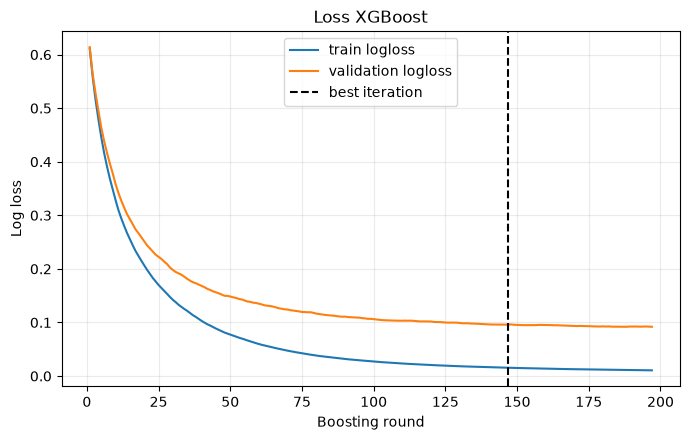

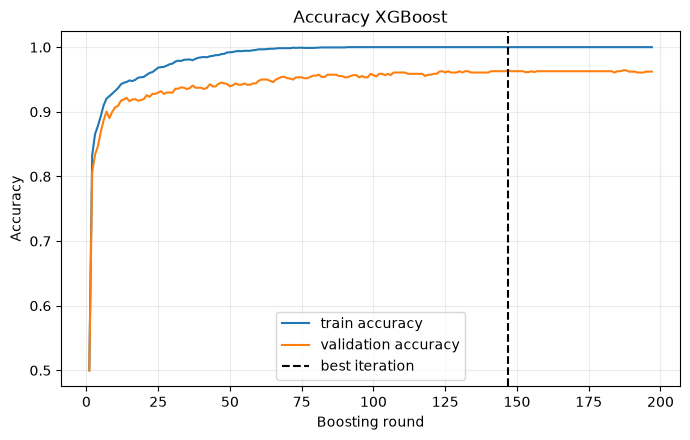

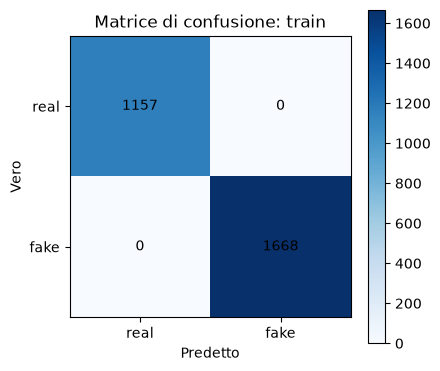

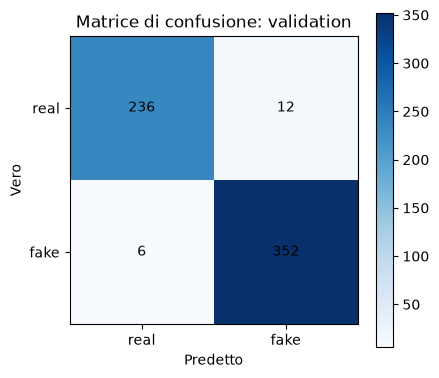

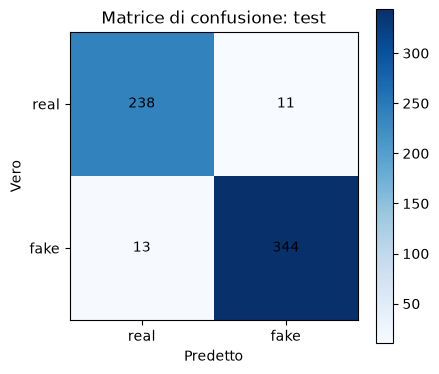

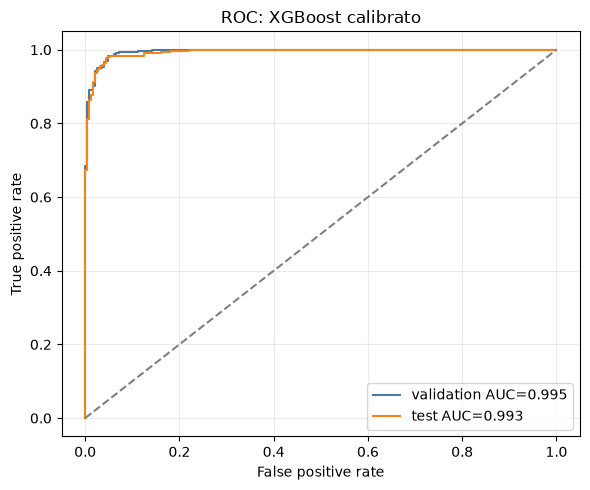

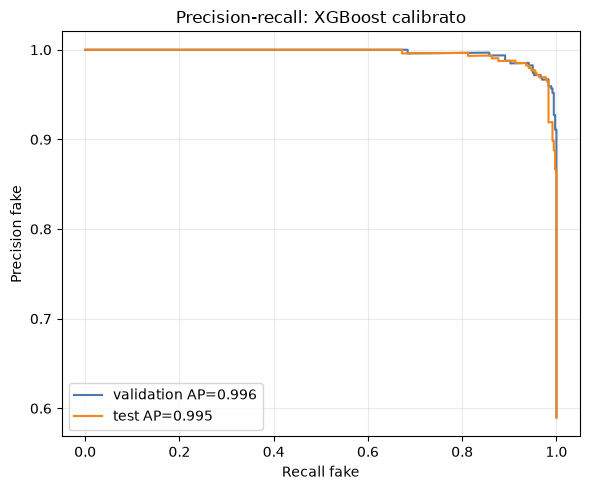

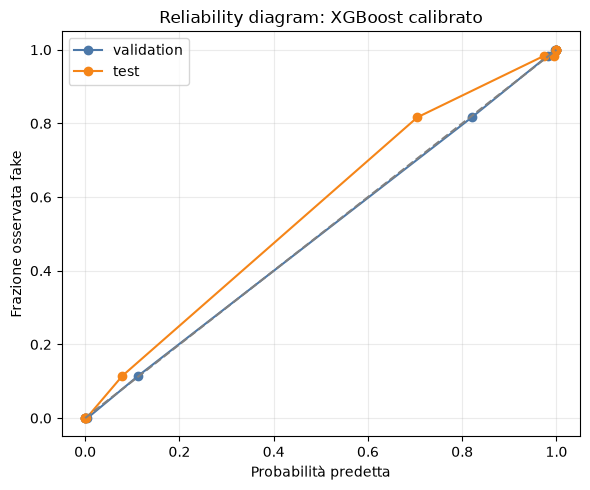

In [13]:
def save_figure(filename):
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()

plt.figure(figsize=(7, 4.5))
plt.plot(history['step'] + 1, history['train_loss'], label='train logloss')
plt.plot(history['step'] + 1, history['val_loss'], label='validation logloss')
plt.axvline(best_iteration + 1, color='black', linestyle='--', label='best iteration')
plt.xlabel('Boosting round')
plt.ylabel('Log loss')
plt.title('Loss XGBoost')
plt.legend()
plt.grid(alpha=0.25)
save_figure('loss_curve.png')

plt.figure(figsize=(7, 4.5))
plt.plot(history['step'] + 1, history['train_accuracy'], label='train accuracy')
plt.plot(history['step'] + 1, history['val_accuracy'], label='validation accuracy')
plt.axvline(best_iteration + 1, color='black', linestyle='--', label='best iteration')
plt.xlabel('Boosting round')
plt.ylabel('Accuracy')
plt.title('Accuracy XGBoost')
plt.legend()
plt.grid(alpha=0.25)
save_figure('accuracy_curve.png')

for split_name in ('train', 'validation', 'test'):
    matrix = evaluations[split_name][2]
    plt.figure(figsize=(4.5, 4))
    image = plt.imshow(matrix, cmap='Blues')
    plt.colorbar(image)
    plt.xticks([0, 1], ['real', 'fake'])
    plt.yticks([0, 1], ['real', 'fake'])
    plt.xlabel('Predetto')
    plt.ylabel('Vero')
    plt.title(f'Matrice di confusione: {split_name}')
    for row in range(2):
        for column in range(2):
            plt.text(column, row, str(matrix[row, column]), ha='center', va='center')
    save_figure(f'confusion_matrix_{split_name}.png')

plt.figure(figsize=(6, 5))
for split_name, y_current, color in (('validation', y_validation, '#4c78a8'), ('test', y_test, '#f58518')):
    probabilities = evaluations[split_name][3]
    fpr, tpr, _ = roc_curve(y_current, probabilities, pos_label=POSITIVE_LABEL)
    plt.plot(fpr, tpr, color=color, label=f'{split_name} AUC={roc_auc_score(y_current, probabilities):.3f}')
plt.plot([0, 1], [0, 1], '--', color='grey')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC: XGBoost calibrato')
plt.legend(loc='lower right')
plt.grid(alpha=0.25)
save_figure('roc_curve.png')

plt.figure(figsize=(6, 5))
for split_name, y_current, color in (('validation', y_validation, '#4c78a8'), ('test', y_test, '#f58518')):
    precision, recall, _ = precision_recall_curve(y_current, evaluations[split_name][3], pos_label=POSITIVE_LABEL)
    plt.plot(recall, precision, color=color, label=f'{split_name} AP={average_precision_score(y_current, evaluations[split_name][3]):.3f}')
plt.xlabel('Recall fake')
plt.ylabel('Precision fake')
plt.title('Precision-recall: XGBoost calibrato')
plt.legend()
plt.grid(alpha=0.25)
save_figure('precision_recall_curve.png')

plt.figure(figsize=(6, 5))
for split_name, y_current, color in (('validation', y_validation, '#4c78a8'), ('test', y_test, '#f58518')):
    observed, predicted = calibration_curve(y_current, evaluations[split_name][3], n_bins=10, strategy='quantile')
    plt.plot(predicted, observed, marker='o', color=color, label=split_name)
plt.plot([0, 1], [0, 1], '--', color='grey')
plt.xlabel('Probabilità predetta')
plt.ylabel('Frazione osservata fake')
plt.title('Reliability diagram: XGBoost calibrato')
plt.legend()
plt.grid(alpha=0.25)
save_figure('calibration_curve.png')

## 8. Salvataggio e verifica del bundle

Il modello nativo JSON è preferito per portabilità. Il bundle joblib aggiunge calibratore Platt, soglia, pooling e metadati. Il file optuna_study.json conserva budget, sampler, pruner, spazio e migliori trial, rendendo auditabile la ricerca bayesiana. Modello JSON e bundle vengono ricaricati e confrontati sulle probabilità di validation prima del riepilogo.

In [14]:
# Il modello base JSON e il calibratore sono entrambi necessari per ricostruire le probabilità dell'ensemble.
NATIVE_MODEL_PATH = RUN_DIR / 'best_model.json'
BUNDLE_PATH = RUN_DIR / 'model_bundle.joblib'
final_model.save_model(NATIVE_MODEL_PATH)
bundle = {'model_name': MODEL_NAME, 'run_id': RUN_ID, 'class_mapping': CLASS_MAPPING, 'positive_class': POSITIVE_CLASS, 'positive_label': POSITIVE_LABEL, 'pooling': selected_pooling, 'feature_dimension': int(X_train.shape[1]), 'selected_hyperparameters': selected_parameters, 'best_iteration': best_iteration, 'threshold': DECISION_THRESHOLD, 'threshold_selection_split': 'validation', 'calibration': {'method': 'Platt logistic regression', 'fit_scope': 'validation only', 'calibrator': calibrator}, 'split_hash': SPLIT_HASH, 'native_model_filename': NATIVE_MODEL_PATH.name, 'xgboost_model': final_model, 'versions': VERSIONS}
joblib.dump(bundle, BUNDLE_PATH)

reloaded_native_model = xgb.XGBClassifier()
reloaded_native_model.load_model(NATIVE_MODEL_PATH)
reloaded_bundle = joblib.load(BUNDLE_PATH)
native_margin = reloaded_native_model.predict(X_validation, output_margin=True)
original_margin = final_model.predict(X_validation, output_margin=True)
reloaded_probability = reloaded_bundle['calibration']['calibrator'].predict_proba(native_margin.reshape(-1, 1))[:, POSITIVE_LABEL]
if not np.allclose(native_margin, original_margin, rtol=1e-6, atol=1e-7):
    raise RuntimeError('I margini del modello JSON ricaricato non coincidono')
if not np.allclose(reloaded_probability, validation_probability, rtol=1e-6, atol=1e-7):
    raise RuntimeError('Le probabilità calibrate ricaricate non coincidono')

summary = {'run_id': RUN_ID, 'model': MODEL_NAME, 'pooling': selected_pooling, 'selected_hyperparameters': selected_parameters, 'best_iteration': best_iteration, 'threshold': DECISION_THRESHOLD, 'split_hash': SPLIT_HASH, 'split_summary': SPLIT_SUMMARY, 'tuning_method': 'Optuna TPESampler with MedianPruner', 'tuning_seconds': tuning_seconds, 'final_fit_seconds': final_fit_seconds, 'model_size_bytes': NATIVE_MODEL_PATH.stat().st_size, 'bundle_size_bytes': BUNDLE_PATH.stat().st_size, 'metrics': metrics_frame.to_dict(orient='records'), 'artifacts': {'native_model': str(NATIVE_MODEL_PATH), 'bundle': str(BUNDLE_PATH), 'history': str(RUN_DIR / 'history.csv'), 'metrics': str(RUN_DIR / 'metrics.csv'), 'predictions': str(RUN_DIR / 'predictions.csv'), 'tuning': str(RUN_DIR / 'tuning_results.csv'), 'optuna_study': str(RUN_DIR / 'optuna_study.json'), 'figures': str(FIGURES_DIR)}}
atomic_json(summary, RUN_DIR / 'summary.json')
print('Ricaricamento JSON e bundle verificato.')
for name, path in summary['artifacts'].items():
    print(f'- {name}: {path}')
display(metrics_frame[['split', 'balanced_accuracy', 'roc_auc', 'pr_auc', 'f1', 'threshold']])

Ricaricamento JSON e bundle verificato.
- native_model: c:\Users\leona\venv_aml\results\xgboost\seed42_20260916T142429Z\best_model.json
- bundle: c:\Users\leona\venv_aml\results\xgboost\seed42_20260916T142429Z\model_bundle.joblib
- history: c:\Users\leona\venv_aml\results\xgboost\seed42_20260916T142429Z\history.csv
- metrics: c:\Users\leona\venv_aml\results\xgboost\seed42_20260916T142429Z\metrics.csv
- predictions: c:\Users\leona\venv_aml\results\xgboost\seed42_20260916T142429Z\predictions.csv
- tuning: c:\Users\leona\venv_aml\results\xgboost\seed42_20260916T142429Z\tuning_results.csv
- optuna_study: c:\Users\leona\venv_aml\results\xgboost\seed42_20260916T142429Z\optuna_study.json
- figures: c:\Users\leona\venv_aml\results\xgboost\seed42_20260916T142429Z\figures


,split,balanced_accuracy,roc_auc,pr_auc,f1,threshold
0,train,1.000000,1.000000,1.000000,1.000000,0.43
1,validation,0.967427,0.994965,0.996345,0.975069,0.43
2,test,0.959704,0.993419,0.995312,0.966292,0.43


## 9. Output e artefatti prodotti

Ogni esecuzione crea una nuova directory results/xgboost/seguita da un run_id contenente seed e data UTC; risultati precedenti non vengono sovrascritti. Tutti i file qui sotto sono persistenti sia in locale sia su Google Drive quando il notebook è eseguito in Colab. In particolare, tuning_results.csv e optuna_study.json rendono verificabile come TPE abbia esplorato lo spazio e quali trial siano stati completati o potati.

| Artefatto | Percorso relativo al run | Contenuto e utilizzo |
|---|---|---|
| Modello nativo | best_model.json | Modello XGBoost nel formato nativo portabile. Produce i margini grezzi usati dal calibratore. |
| Bundle ensemble | model_bundle.joblib | Modello XGBoost, calibratore Platt, pooling selezionato, soglia, iperparametri, mapping classi e hash dello split. È l'artefatto da caricare per l'ensemble. |
| Riepilogo | summary.json | Configurazione selezionata, tempi, dimensioni dei file, metriche e percorsi degli output. |
| Tuning | tuning_results.csv | Una riga per ogni trial TPE: pooling, iperparametri, stato, best iteration, balanced accuracy validation e tempo di fit. |
| Studio Optuna | optuna_study.json | Budget dei trial, seed, sampler TPE, pruner, spazio di ricerca e miglior trial per ciascun pooling. |
| History | history.csv | Logloss e accuracy train/validation a ogni boosting round del modello selezionato. |
| Metriche | metrics.csv | Metriche comuni per train, validation e test: loss, accuracy, balanced accuracy, precision, recall, specificità, F1, ROC-AUC, PR-AUC, Brier score, soglia e tempi. |
| Predizioni | predictions.csv | Una riga per campione con sample_id, origine, split, y_true, raw_score, probability e y_pred. Serve per analisi degli errori e ensemble. |
| Figure | figures/ | loss_curve, accuracy_curve, matrici di confusione, ROC, precision-recall e reliability diagram. |

In aggiunta, il notebook legge e verifica gli artefatti condivisi creati dal notebook esplorativo: artifacts/splits_seed42.npz, dataset/sample_index.csv, dataset/tabular_features_gap.npy e dataset/tabular_features_mean_std.npy. Non modifica mai i due file originali di feature.

Per l'ensemble sono necessari il modello nativo JSON più il calibratore, oppure direttamente il bundle joblib. L'input deve usare il pooling registrato nel bundle e rispettare lo stesso ordine delle feature e lo stesso hash dello split.